In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("gaming_mental_health_10M_40features.csv")
df.head()

,age,gender,income,daily_gaming_hours,weekly_sessions,years_gaming,sleep_hours,caffeine_intake,exercise_hours,stress_level,...,parental_supervision,loneliness_score,aggression_score,happiness_score,bmi,screen_time_total,eye_strain_score,back_pain_score,competitive_rank,internet_quality
0,51,Female,8615,3.68,22,17,5.26,1.00,0.18,3,...,0,2.87,3.19,5.20,19.69,4.71,5.71,4.81,80,10
1,41,Female,39453,5.70,34,16,9.20,0.70,1.44,8,...,7,4.17,7.73,5.40,26.37,6.62,6.77,3.99,57,2
2,27,Male,40466,1.58,8,22,7.39,2.24,3.15,3,...,9,9.38,2.85,5.17,25.15,9.30,2.16,4.75,59,10
3,55,Male,51076,6.11,39,24,7.99,1.65,2.80,1,...,5,8.24,7.19,8.62,26.42,13.81,4.72,5.37,89,1
4,20,Male,86116,3.65,17,0,7.12,1.02,1.01,2,...,9,6.65,2.53,9.71,25.75,10.74,3.90,6.44,15,10


In [3]:
df.columns

Index(['age', 'gender', 'income', 'daily_gaming_hours', 'weekly_sessions',
       'years_gaming', 'sleep_hours', 'caffeine_intake', 'exercise_hours',
       'stress_level', 'anxiety_score', 'depression_score',
       'social_interaction_score', 'relationship_satisfaction',
       'academic_performance', 'work_productivity', 'addiction_level',
       'multiplayer_ratio', 'toxic_exposure', 'violent_games_ratio',
       'mobile_gaming_ratio', 'night_gaming_ratio', 'weekend_gaming_hours',
       'friends_gaming_count', 'online_friends', 'streaming_hours',
       'esports_interest', 'headset_usage', 'microtransactions_spending',
       'parental_supervision', 'loneliness_score', 'aggression_score',
       'happiness_score', 'bmi', 'screen_time_total', 'eye_strain_score',
       'back_pain_score', 'competitive_rank', 'internet_quality'],
      dtype='str')

In [4]:
df.shape

(1000000, 39)

In [5]:
df.nunique()

age                               47
gender                             3
income                        144856
daily_gaming_hours              2287
weekly_sessions                   39
years_gaming                      25
sleep_hours                     1236
caffeine_intake                 1820
exercise_hours                  1821
stress_level                      10
anxiety_score                   1001
depression_score                1001
social_interaction_score        1001
relationship_satisfaction       1001
academic_performance            8246
work_productivity               8239
addiction_level                 1001
multiplayer_ratio                101
toxic_exposure                    96
violent_games_ratio              100
mobile_gaming_ratio              101
night_gaming_ratio               101
weekend_gaming_hours            3316
friends_gaming_count              50
online_friends                   500
streaming_hours                 1229
esports_interest                  11
h

In [6]:
df.isnull().sum()

age                           0
gender                        0
income                        0
daily_gaming_hours            0
weekly_sessions               0
years_gaming                  0
sleep_hours                   0
caffeine_intake               0
exercise_hours                0
stress_level                  0
anxiety_score                 0
depression_score              0
social_interaction_score      0
relationship_satisfaction     0
academic_performance          0
work_productivity             0
addiction_level               0
multiplayer_ratio             0
toxic_exposure                0
violent_games_ratio           0
mobile_gaming_ratio           0
night_gaming_ratio            0
weekend_gaming_hours          0
friends_gaming_count          0
online_friends                0
streaming_hours               0
esports_interest              0
headset_usage                 0
microtransactions_spending    0
parental_supervision          0
loneliness_score              0
aggressi

In [7]:
df.dtypes

age                             int64
gender                            str
income                          int64
daily_gaming_hours            float64
weekly_sessions                 int64
years_gaming                    int64
sleep_hours                   float64
caffeine_intake               float64
exercise_hours                float64
stress_level                    int64
anxiety_score                 float64
depression_score              float64
social_interaction_score      float64
relationship_satisfaction     float64
academic_performance          float64
work_productivity             float64
addiction_level               float64
multiplayer_ratio             float64
toxic_exposure                float64
violent_games_ratio           float64
mobile_gaming_ratio           float64
night_gaming_ratio            float64
weekend_gaming_hours          float64
friends_gaming_count            int64
online_friends                  int64
streaming_hours               float64
esports_inte

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1000000.0,35.986005,13.557163,13.00,24.00,36.00,48.00,59.00
income,1000000.0,77497.675955,41851.540503,5000.00,41258.00,77521.00,113697.00,149999.00
daily_gaming_hours,1000000.0,3.999255,2.826307,0.00,1.92,3.36,5.38,30.42
weekly_sessions,1000000.0,19.997540,11.253438,1.00,10.00,20.00,30.00,39.00
years_gaming,1000000.0,12.002512,7.207838,0.00,6.00,12.00,18.00,24.00
sleep_hours,1000000.0,7.000530,1.501110,-0.17,5.99,7.00,8.01,14.02
caffeine_intake,1000000.0,1.997513,1.996174,0.00,0.58,1.39,2.77,26.90
exercise_hours,1000000.0,1.999008,1.999545,0.00,0.58,1.39,2.77,26.48
stress_level,1000000.0,5.497577,2.873248,1.00,3.00,5.00,8.00,10.00
anxiety_score,1000000.0,4.998644,1.977711,0.00,3.65,5.00,6.35,10.00


In [9]:
print("=" * 60)
print("NUMPY STATISTICS")
print("=" * 60)

num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    print(f"\n{col}:")
    print(f"  Mean     : {np.mean(df[col]):.2f}")
    print(f"  Median   : {np.median(df[col]):.2f}")
    print(f"  Std Dev  : {np.std(df[col]):.2f}")
    print(f"  Min/Max  : {np.min(df[col]):.2f} / {np.max(df[col]):.2f}")
    print(f"  25th pct : {np.percentile(df[col], 25):.2f}")
    print(f"  75th pct : {np.percentile(df[col], 75):.2f}")
    print(f"  Skewness : {pd.Series(df[col]).skew():.2f}")

NUMPY STATISTICS

age:
  Mean     : 35.99
  Median   : 36.00
  Std Dev  : 13.56
  Min/Max  : 13.00 / 59.00
  25th pct : 24.00
  75th pct : 48.00
  Skewness : 0.00

income:
  Mean     : 77497.68
  Median   : 77521.00
  Std Dev  : 41851.52
  Min/Max  : 5000.00 / 149999.00
  25th pct : 41258.00
  75th pct : 113697.00
  Skewness : -0.00

daily_gaming_hours:
  Mean     : 4.00
  Median   : 3.36
  Std Dev  : 2.83
  Min/Max  : 0.00 / 30.42
  25th pct : 1.92
  75th pct : 5.38
  Skewness : 1.40

weekly_sessions:
  Mean     : 20.00
  Median   : 20.00
  Std Dev  : 11.25
  Min/Max  : 1.00 / 39.00
  25th pct : 10.00
  75th pct : 30.00
  Skewness : -0.00

years_gaming:
  Mean     : 12.00
  Median   : 12.00
  Std Dev  : 7.21
  Min/Max  : 0.00 / 24.00
  25th pct : 6.00
  75th pct : 18.00
  Skewness : -0.00

sleep_hours:
  Mean     : 7.00
  Median   : 7.00
  Std Dev  : 1.50
  Min/Max  : -0.17 / 14.02
  25th pct : 5.99
  75th pct : 8.01
  Skewness : -0.00

caffeine_intake:
  Mean     : 2.00
  Median   : 

In [10]:
print("TOP CORRELATIONS WITH MENTAL HEALTH SCORES:\n")
mental_cols = ['stress_level', 'anxiety_score', 'depression_score',
               'happiness_score', 'loneliness_score', 'addiction_level']
corr = df[num_cols].corr()
for col in mental_cols:
    print(f"\n--- Top correlates with {col} ---")
    print(corr[col].drop(mental_cols).abs().sort_values(ascending=False).head(5).round(3))

TOP CORRELATIONS WITH MENTAL HEALTH SCORES:


--- Top correlates with stress_level ---
online_friends                0.003
income                        0.002
microtransactions_spending    0.002
internet_quality              0.001
streaming_hours               0.001
Name: stress_level, dtype: float64

--- Top correlates with anxiety_score ---
academic_performance          0.003
microtransactions_spending    0.002
age                           0.002
screen_time_total             0.002
online_friends                0.001
Name: anxiety_score, dtype: float64

--- Top correlates with depression_score ---
night_gaming_ratio          0.002
bmi                         0.002
social_interaction_score    0.002
headset_usage               0.002
daily_gaming_hours          0.001
Name: depression_score, dtype: float64

--- Top correlates with happiness_score ---
daily_gaming_hours      0.002
sleep_hours             0.001
work_productivity       0.001
violent_games_ratio     0.001
weekend_gaming_hour

C:\Users\USER\AppData\Local\Temp\ipykernel_11988\3595518005.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='gender', y=col, ax=ax2,
C:\Users\USER\AppData\Local\Temp\ipykernel_11988\3595518005.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='gender', y=col, ax=ax2,
C:\Users\USER\AppData\Local\Temp\ipykernel_11988\3595518005.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='gender', y=col, ax=ax2,


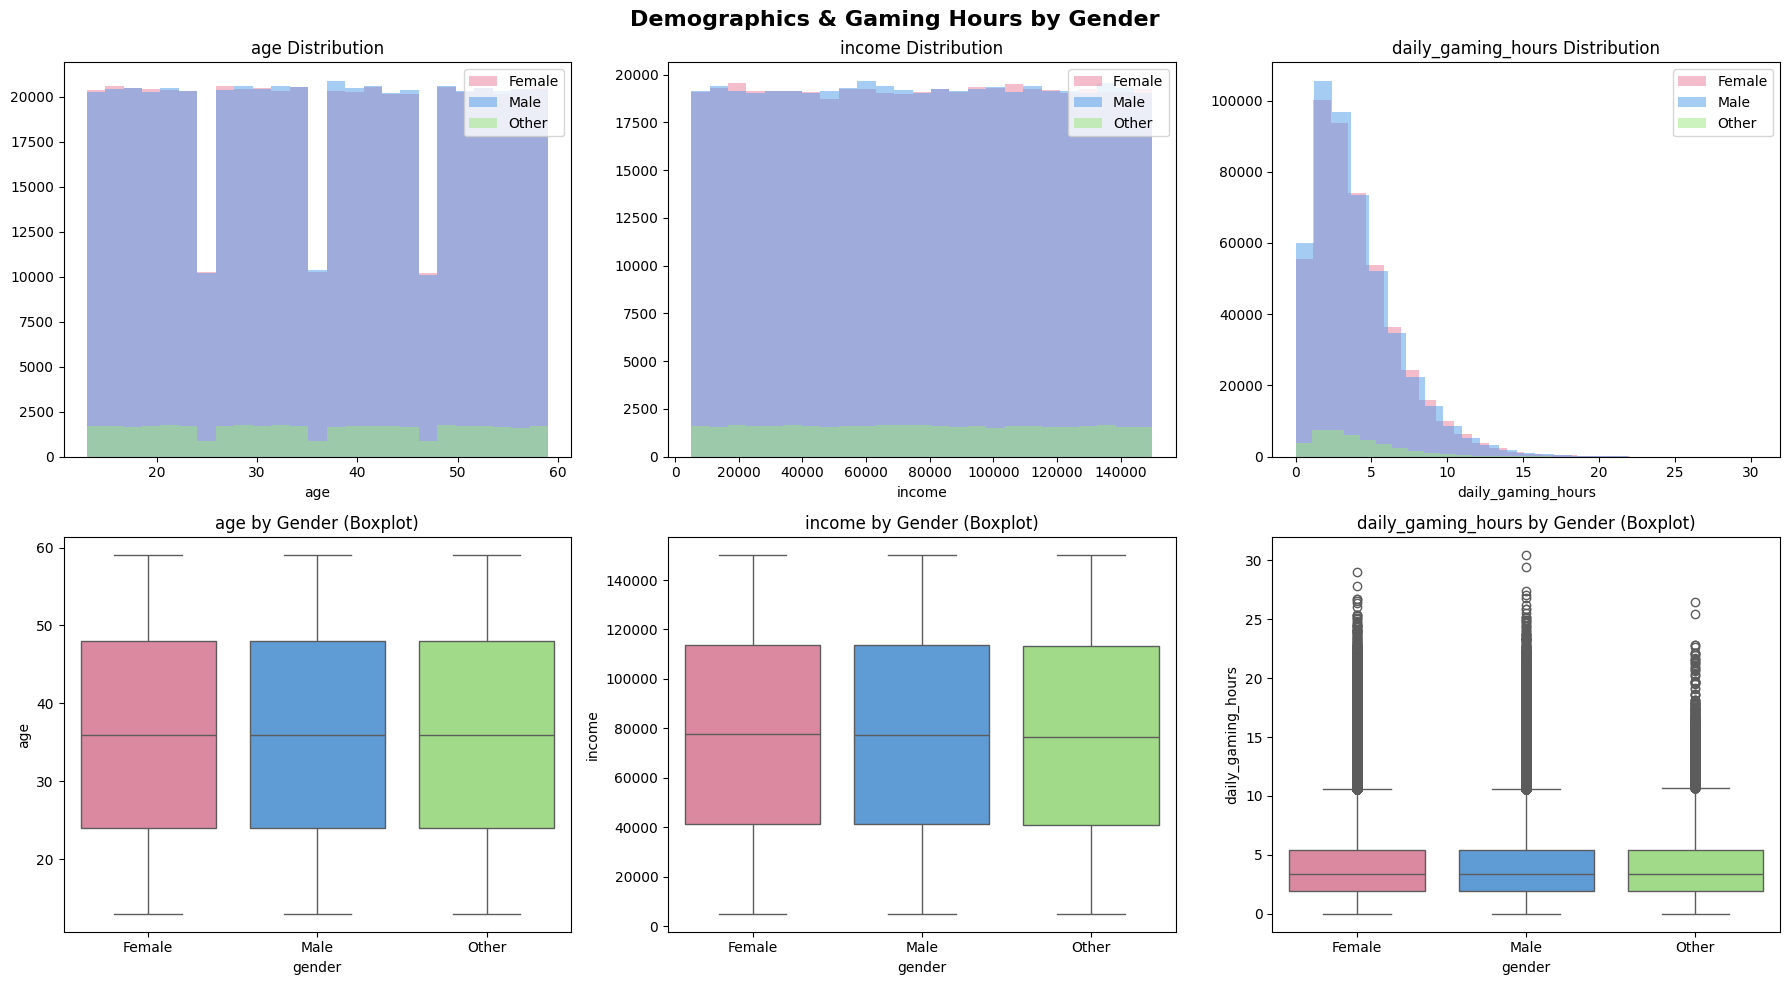

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Demographics & Gaming Hours by Gender', fontsize=16, fontweight='bold')

cols = ['age', 'income', 'daily_gaming_hours']
genders = df['gender'].unique()
palette = {'Male': '#4C9BE8', 'Female': '#E87C9B', 'Other': '#9BE87C'}

for i, col in enumerate(cols):
    # KDE plot
    ax = axes[0, i]
    for g in genders:
        subset = df[df['gender'] == g][col]
        ax.hist(subset, alpha=0.5, label=g, bins=25, color=palette.get(g, 'gray'))
    ax.set_title(f'{col} Distribution')
    ax.set_xlabel(col)
    ax.legend()

    # Boxplot
    ax2 = axes[1, i]
    sns.boxplot(data=df, x='gender', y=col, ax=ax2,
                palette=palette, order=sorted(genders))
    ax2.set_title(f'{col} by Gender (Boxplot)')

plt.tight_layout()
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_11988\1451744053.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='gender', y=col, ax=ax,
C:\Users\USER\AppData\Local\Temp\ipykernel_11988\1451744053.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='gender', y=col, ax=ax,
C:\Users\USER\AppData\Local\Temp\ipykernel_11988\1451744053.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='gender', y=col, ax=ax,


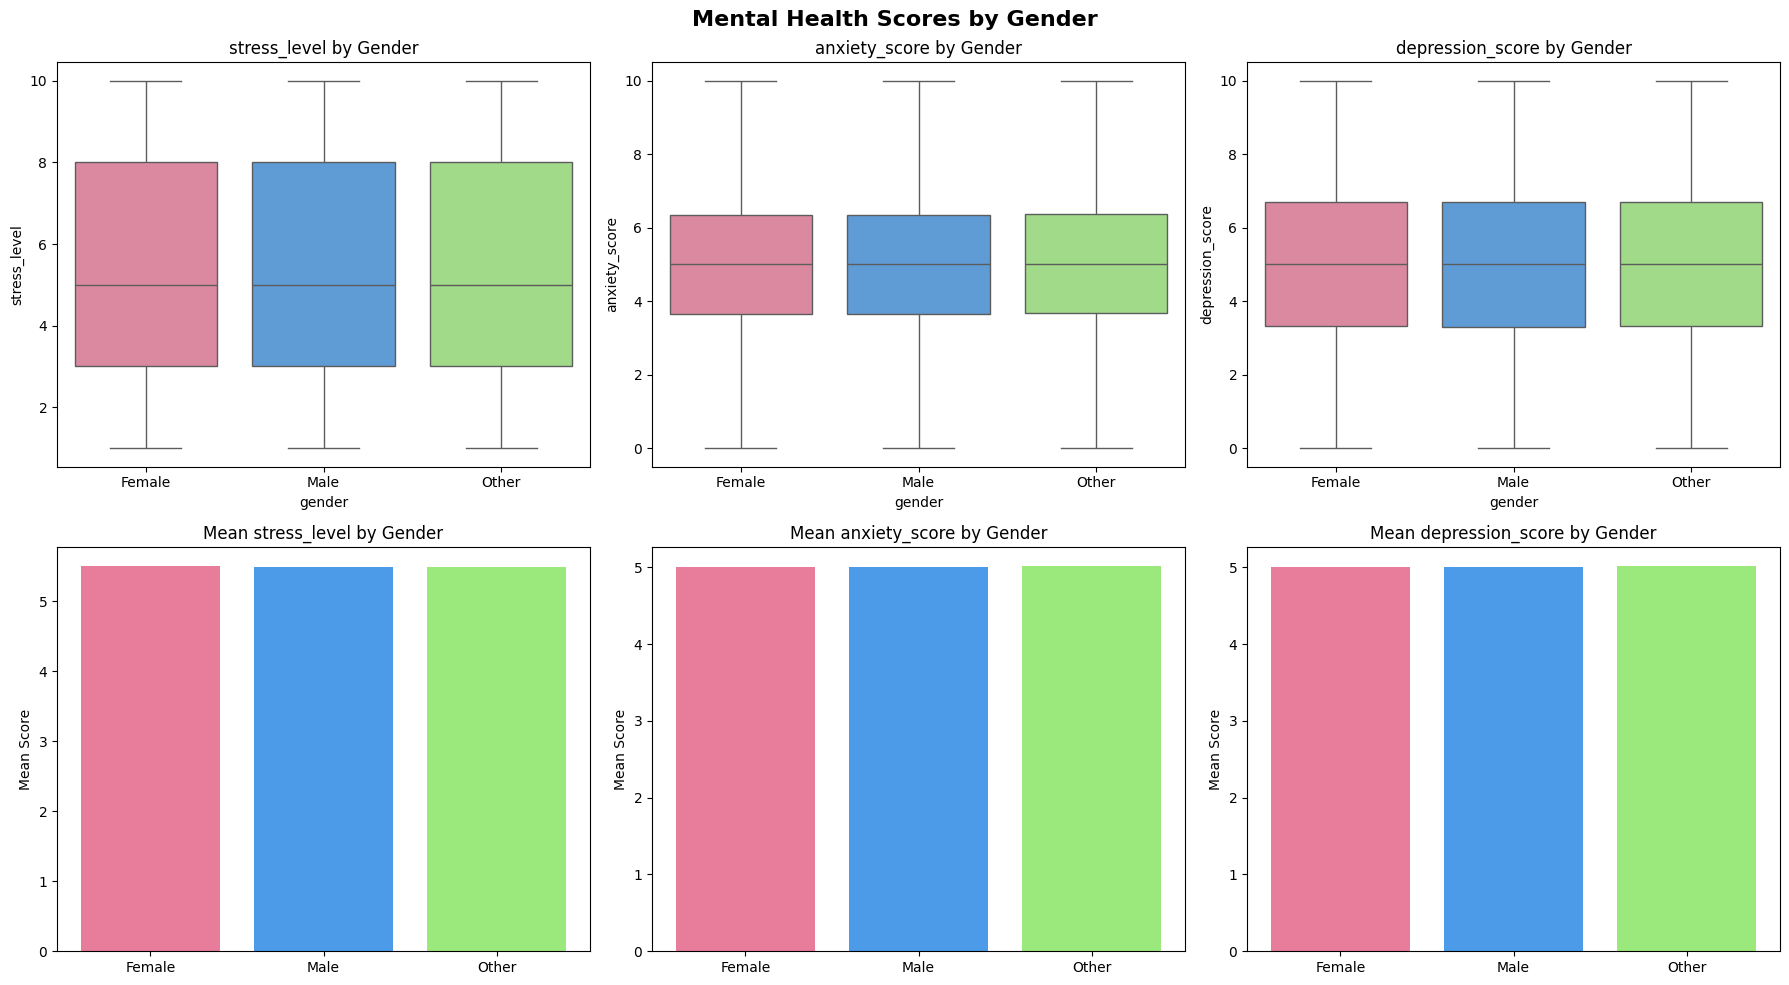

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Mental Health Scores by Gender', fontsize=16, fontweight='bold')

cols = ['stress_level', 'anxiety_score', 'depression_score']

for i, col in enumerate(cols):
    ax = axes[0, i]
    sns.boxplot(data=df, x='gender', y=col, ax=ax,
                palette=palette, order=sorted(genders))
    ax.set_title(f'{col} by Gender')

    ax2 = axes[1, i]
    gender_mean = df.groupby('gender')[col].mean().reindex(sorted(genders))
    ax2.bar(gender_mean.index, gender_mean.values,
            color=[palette.get(g, 'gray') for g in gender_mean.index])
    ax2.set_title(f'Mean {col} by Gender')
    ax2.set_ylabel('Mean Score')

plt.tight_layout()
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_11988\3106738300.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='gender', y=col, ax=ax,
C:\Users\USER\AppData\Local\Temp\ipykernel_11988\3106738300.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='gender', y=col, ax=ax2,
C:\Users\USER\AppData\Local\Temp\ipykernel_11988\3106738300.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='gender', y=col, ax=ax,
C:\Users\USER\AppData\Local\Temp\ipykernel_11988\3106738300.py:13: FutureWarning: 

Passing `palet

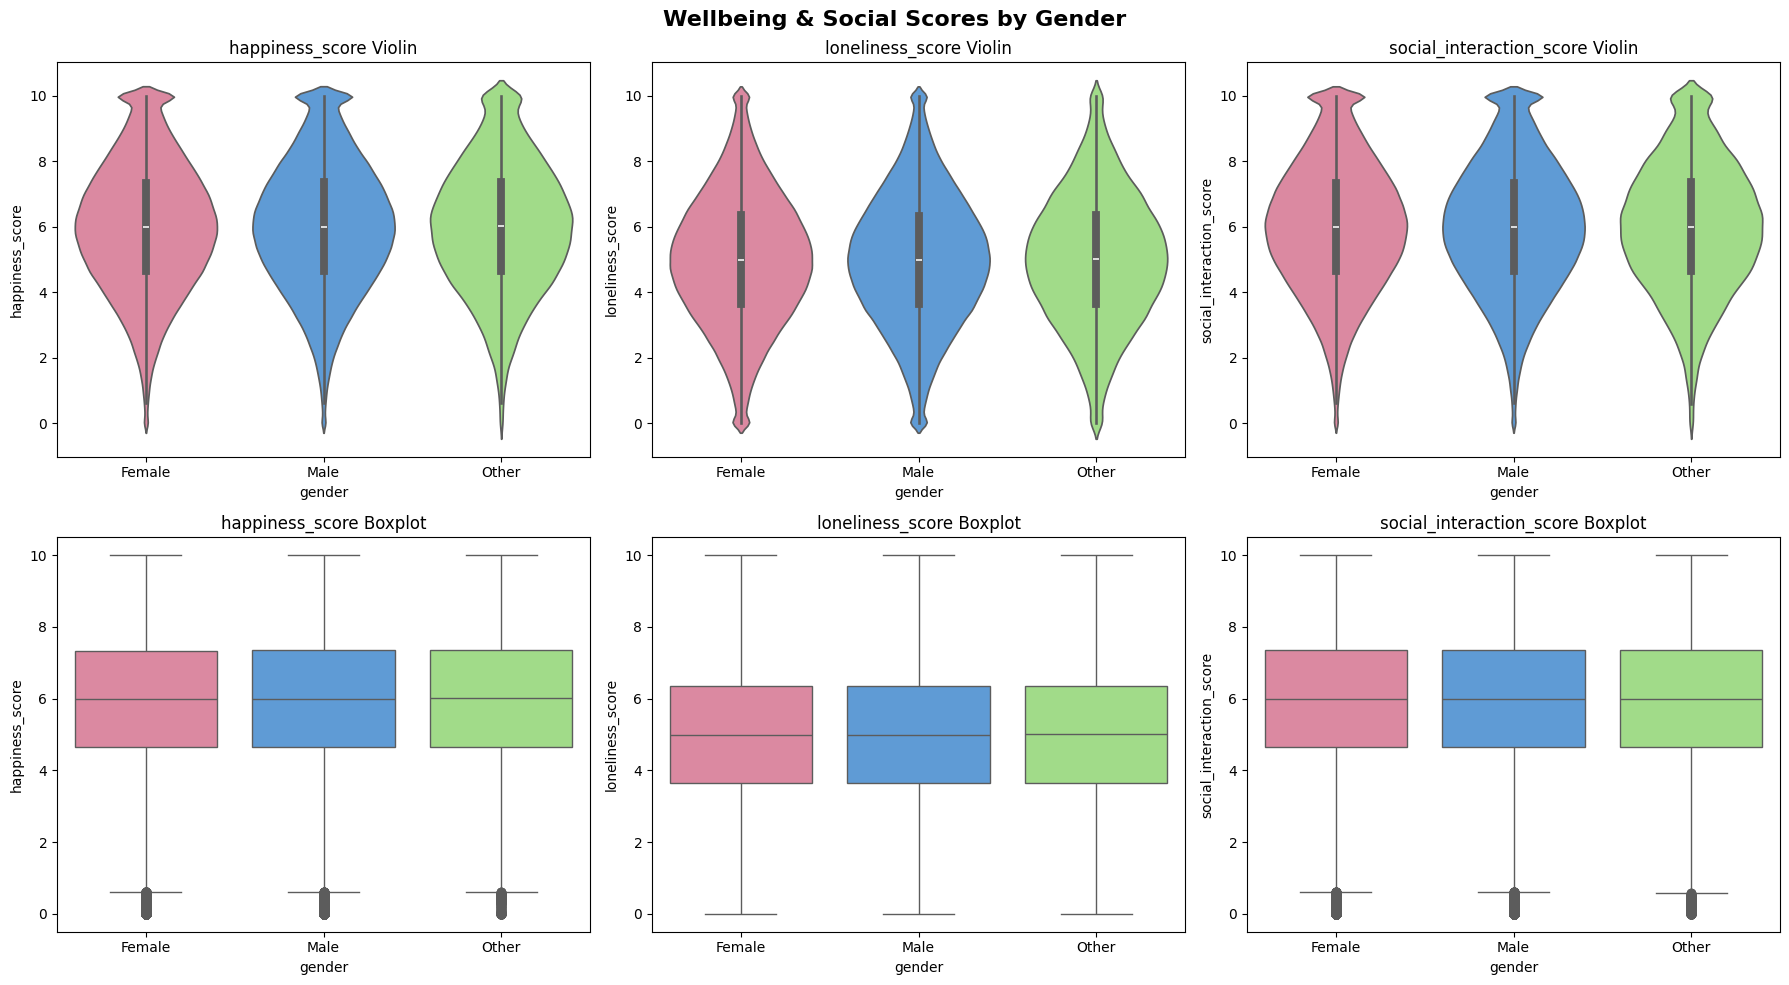

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Wellbeing & Social Scores by Gender', fontsize=16, fontweight='bold')

cols = ['happiness_score', 'loneliness_score', 'social_interaction_score']

for i, col in enumerate(cols):
    ax = axes[0, i]
    sns.violinplot(data=df, x='gender', y=col, ax=ax,
                   palette=palette, order=sorted(genders))
    ax.set_title(f'{col} Violin')

    ax2 = axes[1, i]
    sns.boxplot(data=df, x='gender', y=col, ax=ax2,
                palette=palette, order=sorted(genders))
    ax2.set_title(f'{col} Boxplot')

plt.tight_layout()
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_11988\3031161030.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='gender', y=col, ax=ax,
C:\Users\USER\AppData\Local\Temp\ipykernel_11988\3031161030.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='gender', y=col, ax=ax,
C:\Users\USER\AppData\Local\Temp\ipykernel_11988\3031161030.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='gender', y=col, ax=ax,


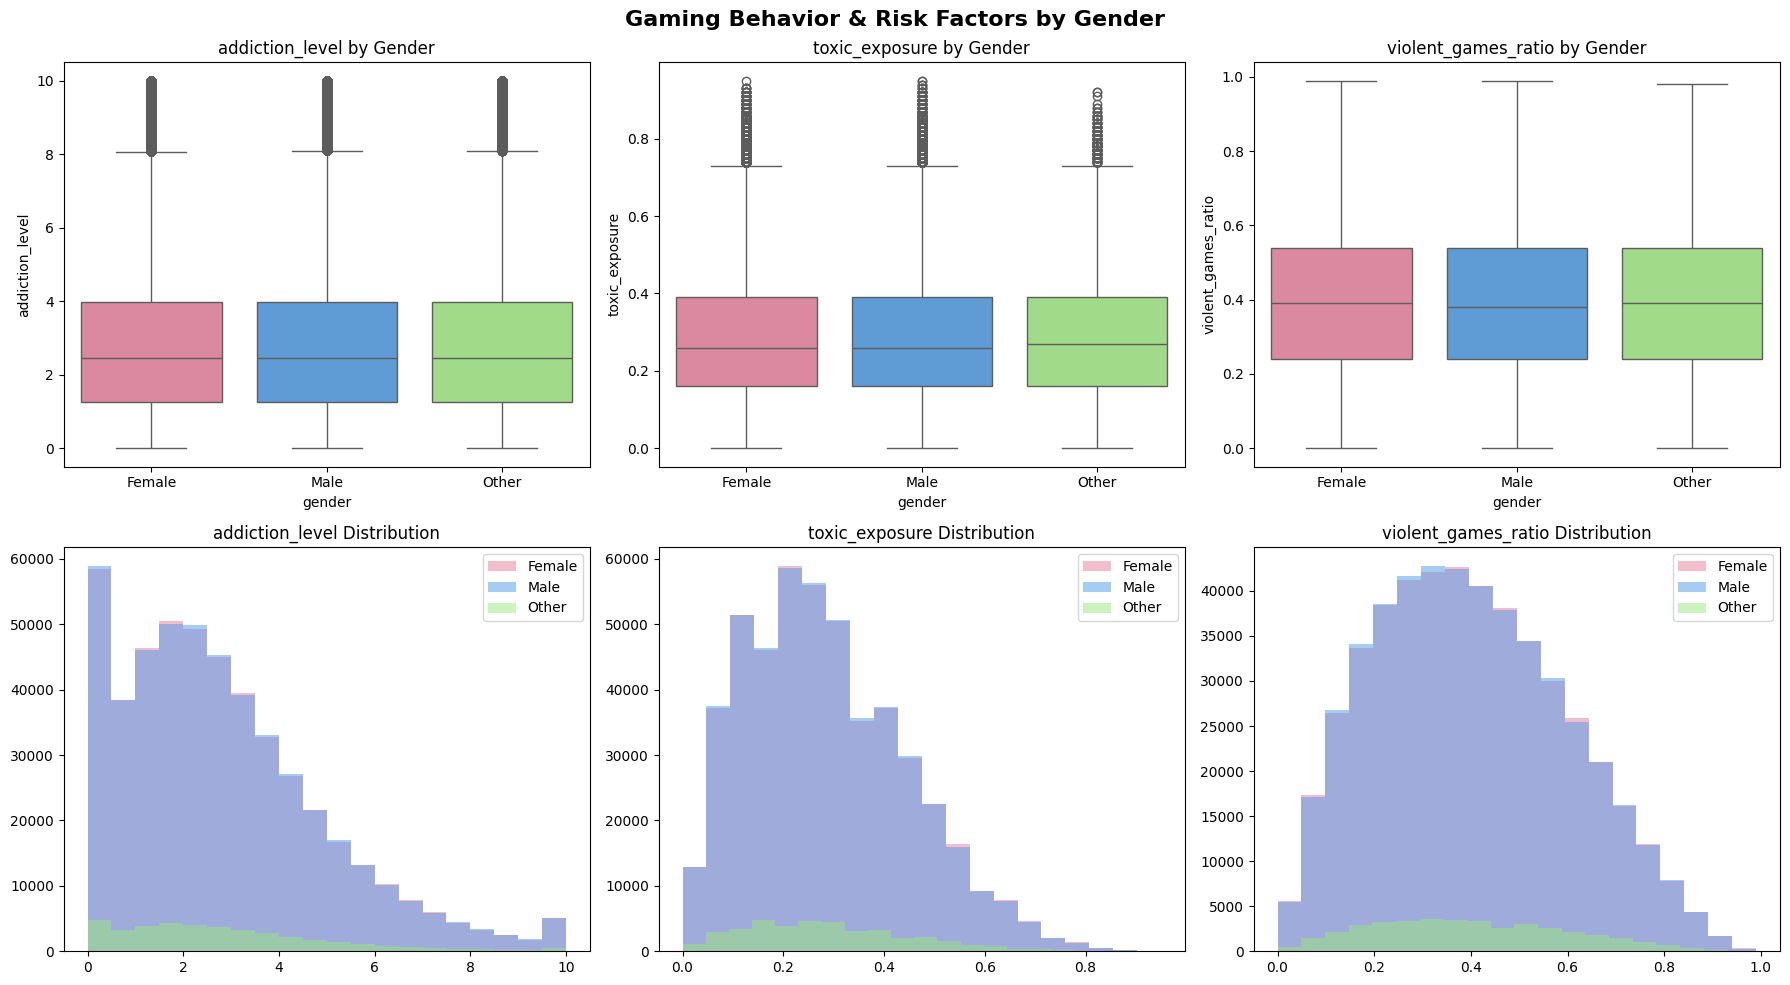

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Gaming Behavior & Risk Factors by Gender', fontsize=16, fontweight='bold')

cols = ['addiction_level', 'toxic_exposure', 'violent_games_ratio']

for i, col in enumerate(cols):
    ax = axes[0, i]
    sns.boxplot(data=df, x='gender', y=col, ax=ax,
                palette=palette, order=sorted(genders))
    ax.set_title(f'{col} by Gender')

    ax2 = axes[1, i]
    for g in genders:
        subset = df[df['gender'] == g][col]
        ax2.hist(subset, alpha=0.5, label=g, bins=20, color=palette.get(g, 'gray'))
    ax2.set_title(f'{col} Distribution')
    ax2.legend()

plt.tight_layout()
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_11988\270244748.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='gender', y=col, ax=axes[i],
C:\Users\USER\AppData\Local\Temp\ipykernel_11988\270244748.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='gender', y=col, ax=axes[i],


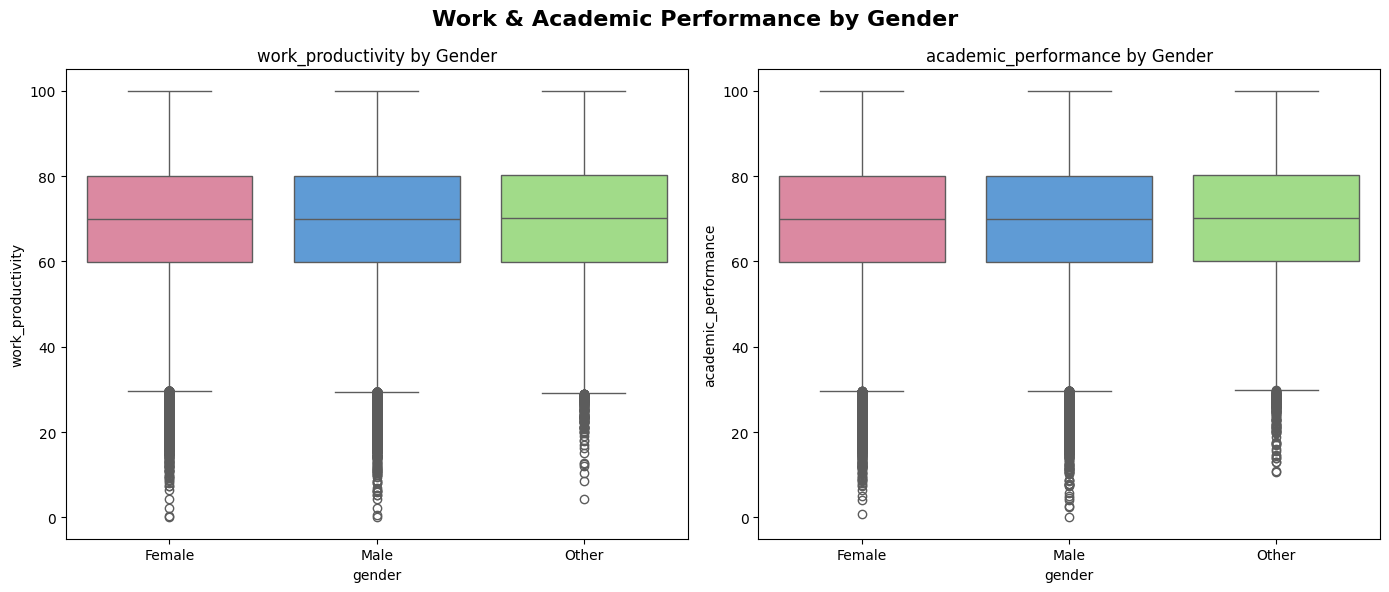

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Work & Academic Performance by Gender', fontsize=16, fontweight='bold')

for i, col in enumerate(['work_productivity', 'academic_performance']):
    sns.boxplot(data=df, x='gender', y=col, ax=axes[i],
                palette=palette, order=sorted(genders))
    axes[i].set_title(f'{col} by Gender')

plt.tight_layout()
plt.show()

In [17]:
def classify_gamer(row):
    conditions = [
        row['sleep_hours'] >= 6,
        row['exercise_hours'] >= 1,
        row['stress_level'] <= 5,
        row['anxiety_score'] <= 5.0,
        row['depression_score'] <= 5.0,
        row['addiction_level'] <= 5.0,
        18.5 <= row['bmi'] <= 29.9,
        row['happiness_score'] >= 5.0,
        row['loneliness_score'] <= 5.0,
        row['aggression_score'] <= 5.0,
    ]
    score = sum(conditions)
    if score >= 8:
        return 'Healthy Gamer'
    elif score >= 5:
        return 'Moderate Gamer'
    else:
        return 'Unhealthy Gamer'

df['gamer_health_status'] = df.apply(classify_gamer, axis=1)

print("Healthy Gamer Classification Distribution:")
print(df['gamer_health_status'].value_counts())
print("\nBy Gender:")
print(pd.crosstab(df['gender'], df['gamer_health_status']))

Healthy Gamer Classification Distribution:
gamer_health_status
Moderate Gamer     685588
Healthy Gamer      198762
Unhealthy Gamer    115650
Name: count, dtype: int64

By Gender:
gamer_health_status  Healthy Gamer  Moderate Gamer  Unhealthy Gamer
gender                                                             
Female                       95426          328547            55606
Male                         95554          329535            55492
Other                         7782           27506             4552


In [19]:
print("=" * 65)
print("KEY INSIGHTS — GAMING & MENTAL HEALTH EDA")
print("=" * 65)

total = len(df)
for status in ['Healthy Gamer', 'Moderate Gamer', 'Unhealthy Gamer']:
    count = (df['gamer_health_status'] == status).sum()
    print(f"\n{status}: {count} ({count/total*100:.1f}%)")

print("\n--- Gender-wise Health Status ---")
print(pd.crosstab(df['gender'], df['gamer_health_status'], normalize='index').round(3) * 100)

print("\n--- Mean Key Metrics by Health Status ---")
insight_cols = ['daily_gaming_hours', 'sleep_hours', 'exercise_hours',
                'stress_level', 'anxiety_score', 'depression_score',
                'happiness_score', 'addiction_level', 'bmi']
print(df.groupby('gamer_health_status')[insight_cols].mean().round(2).T)

print("\n--- Gender-wise Mean Mental Health ---")
print(df.groupby('gender')[['stress_level', 'anxiety_score', 'depression_score',
                             'happiness_score', 'loneliness_score']].mean().round(2))

KEY INSIGHTS — GAMING & MENTAL HEALTH EDA

Healthy Gamer: 198762 (19.9%)

Moderate Gamer: 685588 (68.6%)

Unhealthy Gamer: 115650 (11.6%)

--- Gender-wise Health Status ---
gamer_health_status  Healthy Gamer  Moderate Gamer  Unhealthy Gamer
gender                                                             
Female                        19.9            68.5             11.6
Male                          19.9            68.6             11.5
Other                         19.5            69.0             11.4

--- Mean Key Metrics by Health Status ---
gamer_health_status  Healthy Gamer  Moderate Gamer  Unhealthy Gamer
daily_gaming_hours            3.43            3.99             5.05
sleep_hours                   7.41            6.99             6.35
exercise_hours                2.57            1.96             1.26
stress_level                  4.22            5.64             6.87
anxiety_score                 4.19            5.09             5.88
depression_score              4.00  

In [5]:
df_encoded = pd.get_dummies(df, drop_first=True)
corr = df_encoded.corr()
print(corr)

                                 age    income  daily_gaming_hours  \
age                         1.000000 -0.001215           -0.001483   
income                     -0.001215  1.000000           -0.000068   
daily_gaming_hours         -0.001483 -0.000068            1.000000   
weekly_sessions             0.000711  0.000112            0.001608   
years_gaming               -0.000986  0.000102           -0.000161   
sleep_hours                -0.000853  0.001912           -0.000426   
caffeine_intake             0.000186  0.000855            0.002559   
exercise_hours              0.001511 -0.001546           -0.000208   
stress_level               -0.000668 -0.001890           -0.000230   
anxiety_score              -0.001986  0.001066            0.000548   
depression_score            0.001057  0.000663           -0.001477   
social_interaction_score    0.000553 -0.000150            0.000349   
relationship_satisfaction   0.000713  0.000791           -0.000208   
academic_performance

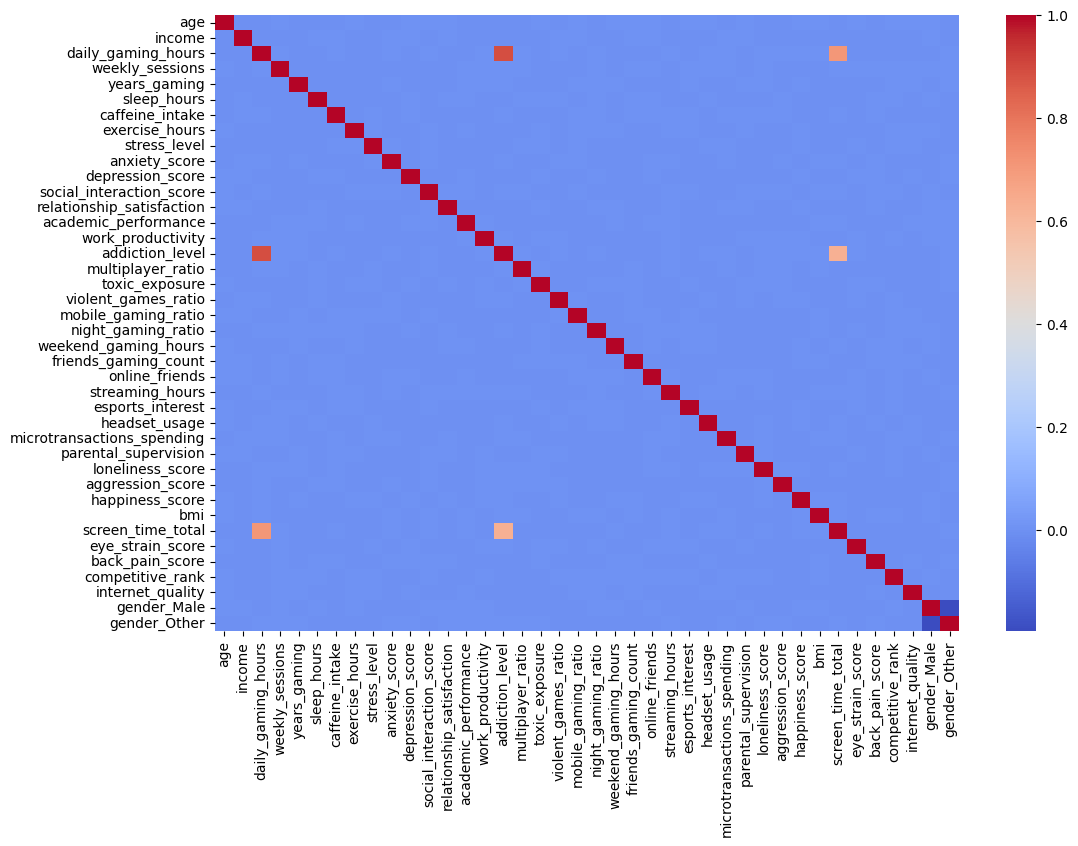

In [6]:
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=False,cmap="coolwarm")
plt.show()